<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/Week03_EDA_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Hücre 0b — Week 2'de indirdiğimiz veriyi /content/'e geri açalım
# Çünkü /content her oturumda sıfırlanır, ama Drive'da saklı
import os, shutil
DRIVE_DATA = "/content/drive/MyDrive/PneumoniaDetection/data/raw/chest_xray"
LOCAL_DATA = "/content/chest_xray"

if not os.path.isdir(LOCAL_DATA):
    print("Drive'dan local'e kopyalanıyor (5-10 dakika sürebilir)...")
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print("Tamam.")
else:
    print("Veri zaten /content/chest_xray içinde.")

Drive'dan local'e kopyalanıyor (5-10 dakika sürebilir)...
Tamam.


In [3]:
# === Standard library ===
import os                             # File system operations
import re                             # Regex for filename parsing
import shutil                         # Recursive directory removal
import random                         # Reproducible sampling
from pathlib import Path              # Modern, OS-agnostic path handling

# === Numerical / data ===
import numpy as np                    # Array math
import pandas as pd                   # Manifest DataFrame
from PIL import Image                 # Image I/O and verification

# === Visualization ===
import matplotlib.pyplot as plt       # Base plotting
import seaborn as sns                 # Higher-level statistical plots
sns.set_style("whitegrid")            # Cleaner default aesthetic

# === ML utilities ===
from sklearn.model_selection import StratifiedGroupKFold   # Patient-aware stratified split
import tensorflow as tf                                    # For Cell 6 generators

# === Reproducibility ===
RANDOM_SEED = 42                      # Single source of truth for all randomness
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# === Canonical paths ===
PROJECT_ROOT  = Path("/content/drive/MyDrive/PneumoniaDetection")
DATA_DIR      = Path("/content/chest_xray")              # Read-only working copy from Week 2
SPLITS_DIR    = Path("/content/chest_xray_splits")       # Symlink directory, rebuilt each run
REPORTS_DIR   = PROJECT_ROOT / "reports"
FIGURES_DIR   = REPORTS_DIR / "figures"
MANIFEST_PATH = REPORTS_DIR / "manifest.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Paths initialized. Working from:", DATA_DIR)

Paths initialized. Working from: /content/chest_xray


In [4]:
# ---- 2a. Build the full image manifest -------------------------------
def list_images(folder: Path):
    """Case-insensitive enumeration of jpeg/jpg files in a folder."""
    files = []
    for ext in ("*.jpeg", "*.jpg", "*.JPEG", "*.JPG"):
        files.extend(folder.glob(ext))
    return sorted(set(files))                   # Dedupe + deterministic order

records = []
for split_orig in ("train", "val", "test"):
    for cls in ("NORMAL", "PNEUMONIA"):
        for img_path in list_images(DATA_DIR / split_orig / cls):
            records.append({
                "filepath":   str(img_path),
                "filename":   img_path.name,
                "class":      cls,
                "split_orig": split_orig,
            })

manifest = pd.DataFrame(records)
print(f"Total images discovered: {len(manifest)}")

# ---- 2b. Extract patient_group and etiology from filenames -----------
def extract_patient_group(filename: str, cls: str) -> str:
    """Heuristic patient-ID extraction. PNEUMONIA is reliable; NORMAL is best-effort."""
    if cls == "PNEUMONIA":
        m = re.search(r"person(\d+)", filename)
        if m:
            return f"pneu_p{m.group(1)}"
    else:  # NORMAL — use IM-NNNN prefix as pseudo-patient
        m = re.search(r"IM-(\d+)", filename)
        if m:
            return f"norm_IM{m.group(1)}"
    # Fallback: each image is its own singleton group (no overlap constraint)
    return f"singleton_{filename}"

def extract_etiology(filename: str, cls: str) -> str:
    """Recover bacterial/viral subtype from PNEUMONIA filenames."""
    if cls == "NORMAL":
        return "none"
    if "bacteria" in filename.lower():
        return "bacteria"
    if "virus" in filename.lower():
        return "virus"
    return "unknown"

manifest["patient_group"] = manifest.apply(
    lambda r: extract_patient_group(r["filename"], r["class"]), axis=1
)
manifest["etiology"] = manifest.apply(
    lambda r: extract_etiology(r["filename"], r["class"]), axis=1
)

# ---- 2c. Initialize the new 'split' column --------------------------
# Default: copy from split_orig, but rename the original 'val' to 'val_original'
manifest["split"] = manifest["split_orig"].replace({"val": "val_original"})

# ---- 2d. Carve val_split from train using StratifiedGroupKFold ------
train_mask = manifest["split"] == "train"
train_idx_in_manifest = manifest.index[train_mask].to_numpy()

y      = manifest.loc[train_mask, "class"].to_numpy()
groups = manifest.loc[train_mask, "patient_group"].to_numpy()

sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
train_local_idx, val_local_idx = next(sgkf.split(train_idx_in_manifest, y, groups))

# Map the local fold indices back to the global manifest indices
train_global = train_idx_in_manifest[train_local_idx]
val_global   = train_idx_in_manifest[val_local_idx]

manifest.loc[train_global, "split"] = "train_split"
manifest.loc[val_global,   "split"] = "val_split"

# ---- 2e. SANITY CHECKS — fail loudly if anything is wrong -----------
assert manifest["split"].isin(
    {"train_split", "val_split", "val_original", "test"}
).all(), "Unexpected split label produced."

train_groups = set(manifest.loc[manifest["split"] == "train_split", "patient_group"])
val_groups   = set(manifest.loc[manifest["split"] == "val_split",   "patient_group"])
overlap = train_groups & val_groups
# Allow only singleton fallback groups in the overlap (we documented this limitation)
real_overlap = {g for g in overlap if not g.startswith("singleton_")}
assert len(real_overlap) == 0, f"Patient overlap detected: {real_overlap}"
print(f"Patient-disjoint check passed. (Singleton groups in both: "
      f"{len(overlap) - len(real_overlap)}, by construction.)")

# ---- 2f. Print the final split summary ------------------------------
summary = (manifest.groupby(["split", "class"]).size()
                   .unstack(fill_value=0)
                   .reindex(["train_split", "val_split", "val_original", "test"]))
summary["TOTAL"]   = summary.sum(axis=1)
summary["PNEU%"] = (summary["PNEUMONIA"] /
                      summary[["NORMAL", "PNEUMONIA"]].sum(axis=1) * 100).round(1)
print("\n=== New split distribution ===")
print(summary)

# ---- 2g. Persist manifest + materialize symlink directory -----------
manifest.to_csv(MANIFEST_PATH, index=False)
print(f"\nManifest saved to: {MANIFEST_PATH}")

# Idempotent rebuild of the symlink tree
if SPLITS_DIR.exists():
    shutil.rmtree(SPLITS_DIR)

split_to_dir = {
    "train_split":  "train",
    "val_split":    "val",
    "val_original": "val_original",
    "test":         "test",
}
for d in split_to_dir.values():
    for cls in ("NORMAL", "PNEUMONIA"):
        (SPLITS_DIR / d / cls).mkdir(parents=True, exist_ok=True)

for _, row in manifest.iterrows():
    src = Path(row["filepath"])
    dst = SPLITS_DIR / split_to_dir[row["split"]] / row["class"] / src.name
    if not dst.exists():
        os.symlink(src, dst)

print(f"Symlink tree rebuilt at: {SPLITS_DIR}")

Total images discovered: 5856
Patient-disjoint check passed. (Singleton groups in both: 0, by construction.)

=== New split distribution ===
class         NORMAL  PNEUMONIA  TOTAL  PNEU%
split                                        
train_split     1213       3509   4722   74.3
val_split        128        366    494   74.1
val_original       8          8     16   50.0
test             234        390    624   62.5

Manifest saved to: /content/drive/MyDrive/PneumoniaDetection/reports/manifest.csv
Symlink tree rebuilt at: /content/chest_xray_splits


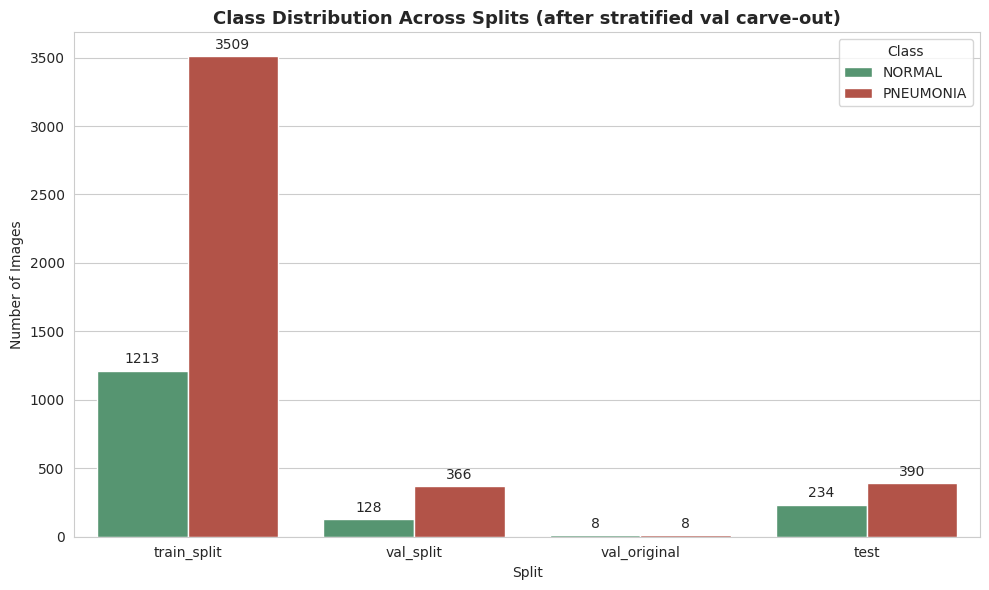

Saved: /content/drive/MyDrive/PneumoniaDetection/reports/figures/fig01_class_distribution.png


In [5]:
# Aggregate counts per (split, class)
plot_df = (manifest.groupby(["split", "class"])
                   .size().reset_index(name="count"))

# Enforce a sensible split order on the x-axis
split_order = ["train_split", "val_split", "val_original", "test"]
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df, x="split", y="count", hue="class",
    palette={"NORMAL": "#4C9F70", "PNEUMONIA": "#C44536"},
    ax=ax,
)

# Annotate each bar with its absolute count
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

ax.set_title("Class Distribution Across Splits (after stratified val carve-out)",
             fontsize=13, weight="bold")
ax.set_xlabel("Split"); ax.set_ylabel("Number of Images")
ax.legend(title="Class", loc="upper right")
plt.tight_layout()

out_path = FIGURES_DIR / "fig01_class_distribution.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

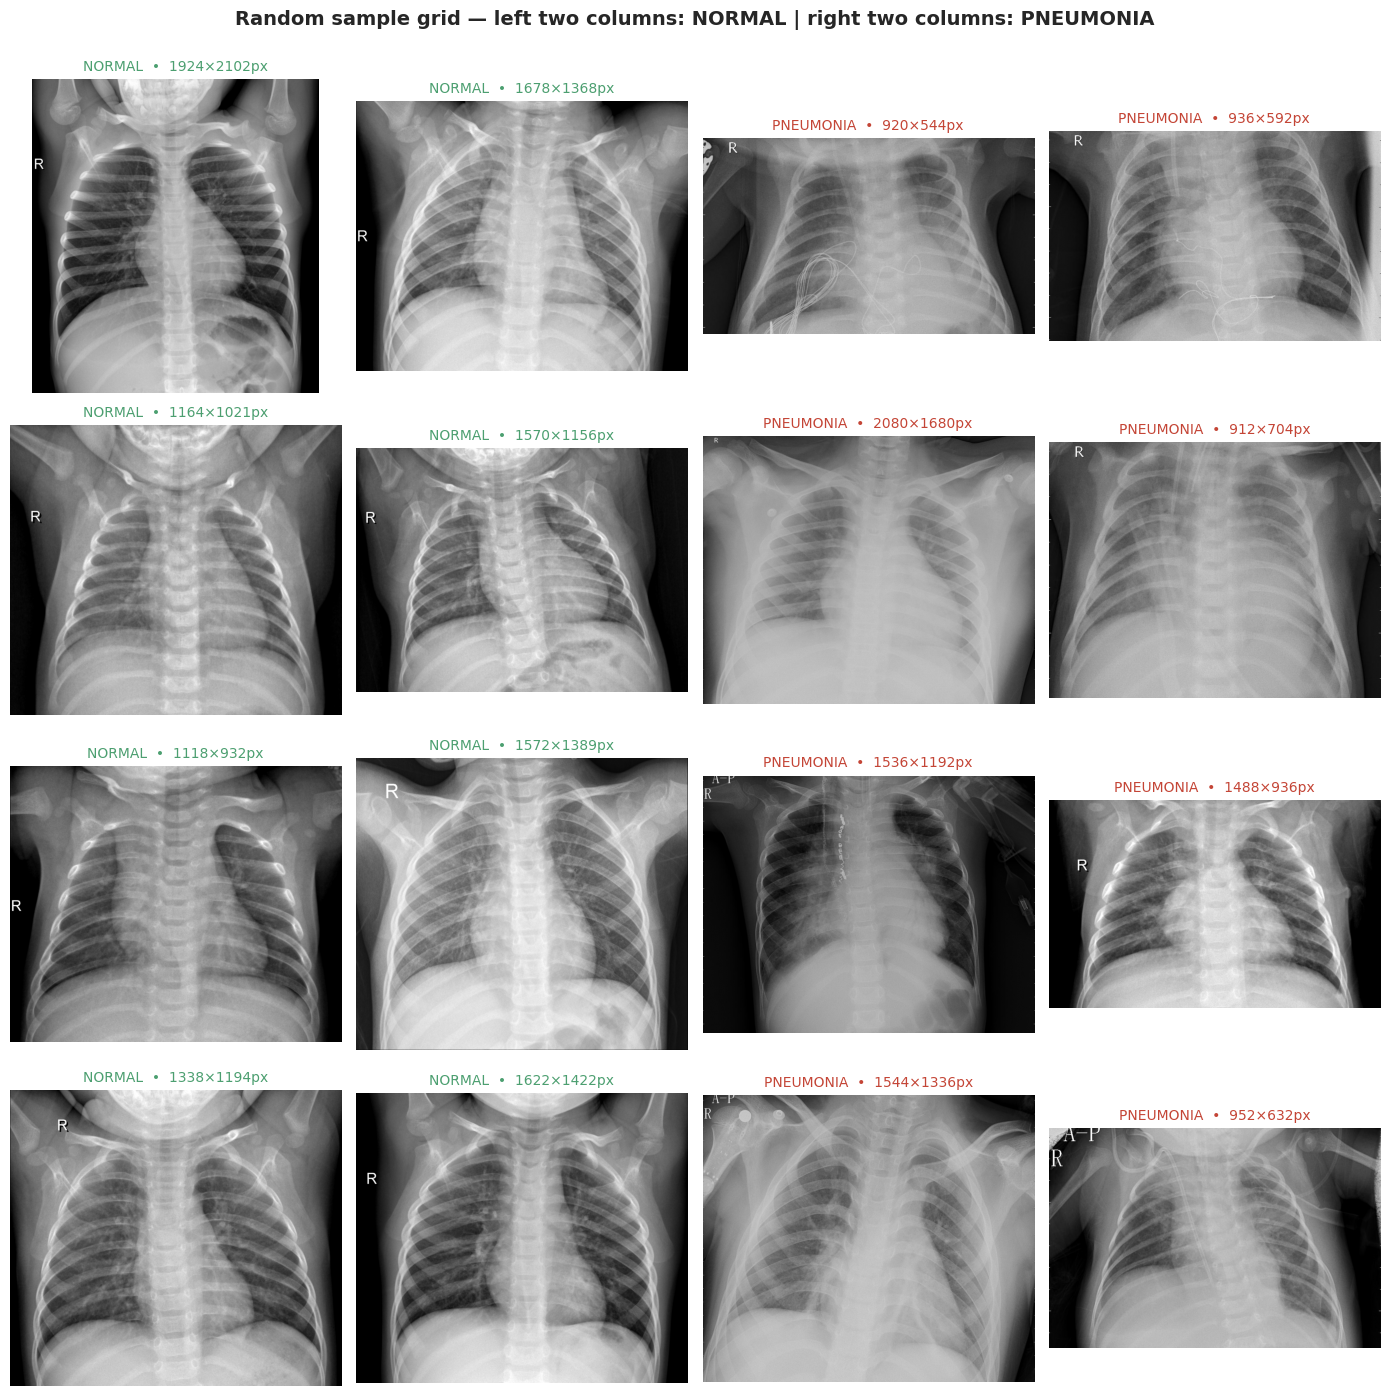

Saved: /content/drive/MyDrive/PneumoniaDetection/reports/figures/fig02_sample_grid.png


In [6]:
# Source pool: only train_split (we never peek at test images during EDA)
pool = manifest[manifest["split"] == "train_split"]

# Reproducible sample: 8 NORMAL + 8 PNEUMONIA
rng = np.random.default_rng(RANDOM_SEED)
normal_samples = pool[pool["class"] == "NORMAL"].sample(8, random_state=RANDOM_SEED)
pneumo_samples = pool[pool["class"] == "PNEUMONIA"].sample(8, random_state=RANDOM_SEED)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Random sample grid — left two columns: NORMAL | right two columns: PNEUMONIA",
             fontsize=14, weight="bold", y=1.00)

# Build the 16-cell layout: rows × (NORMAL,NORMAL,PNEUMONIA,PNEUMONIA)
for row in range(4):
    for col in range(4):
        ax = axes[row, col]
        if col < 2:                                   # NORMAL columns
            sample_idx = row * 2 + col
            row_data = normal_samples.iloc[sample_idx]
            border_color = "#4C9F70"
        else:                                          # PNEUMONIA columns
            sample_idx = row * 2 + (col - 2)
            row_data = pneumo_samples.iloc[sample_idx]
            border_color = "#C44536"

        img = Image.open(row_data["filepath"])
        w, h = img.size
        ax.imshow(img, cmap="gray")
        ax.set_title(f"{row_data['class']}  •  {w}×{h}px",
                     fontsize=10, color=border_color)
        ax.axis("off")
        # Colored border to reinforce the class assignment visually
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_edgecolor(border_color); spine.set_linewidth(2)

plt.tight_layout()
out_path = FIGURES_DIR / "fig02_sample_grid.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

Computing mean histograms over 200 NORMAL and 200 PNEUMONIA images...


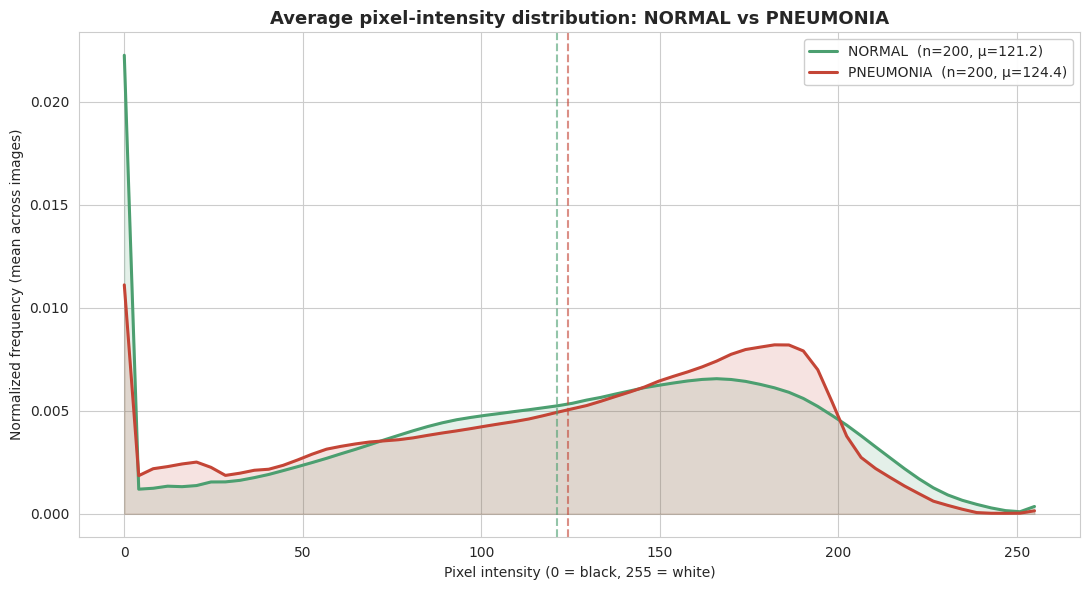


Mean intensity gap: 3.17
Interpret: gaps > 15 suggest the model could shortcut on brightness alone.
Saved: /content/drive/MyDrive/PneumoniaDetection/reports/figures/fig03_intensity_histogram.png


In [7]:
# Sample 200 images per class from train_split — enough for stable mean histogram
N_PER_CLASS = 200

normal_samples = (manifest[(manifest["split"] == "train_split") &
                           (manifest["class"] == "NORMAL")]
                  .sample(min(N_PER_CLASS, sum((manifest["split"] == "train_split") &
                                                (manifest["class"] == "NORMAL"))),
                          random_state=RANDOM_SEED))
pneumo_samples = (manifest[(manifest["split"] == "train_split") &
                           (manifest["class"] == "PNEUMONIA")]
                  .sample(N_PER_CLASS, random_state=RANDOM_SEED))

def compute_mean_histogram(filepaths, bins=64):
    """Average per-pixel-intensity histogram across a set of grayscale images."""
    hist_sum = np.zeros(bins, dtype=np.float64)
    n_processed = 0
    for fp in filepaths:
        try:
            arr = np.array(Image.open(fp).convert("L"))   # Force grayscale
            h, _ = np.histogram(arr, bins=bins, range=(0, 255), density=True)
            hist_sum += h
            n_processed += 1
        except Exception as e:
            print(f"  Skipped {fp} ({e})")
    return hist_sum / max(n_processed, 1), n_processed

print(f"Computing mean histograms over {len(normal_samples)} NORMAL "
      f"and {len(pneumo_samples)} PNEUMONIA images...")
hist_normal, n_n = compute_mean_histogram(normal_samples["filepath"].tolist())
hist_pneumo, n_p = compute_mean_histogram(pneumo_samples["filepath"].tolist())

bins = np.linspace(0, 255, len(hist_normal))
mean_normal = (bins * hist_normal).sum() / hist_normal.sum()
mean_pneumo = (bins * hist_pneumo).sum() / hist_pneumo.sum()

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(bins, hist_normal, label=f"NORMAL  (n={n_n}, μ={mean_normal:.1f})",
        color="#4C9F70", linewidth=2.2)
ax.plot(bins, hist_pneumo, label=f"PNEUMONIA  (n={n_p}, μ={mean_pneumo:.1f})",
        color="#C44536", linewidth=2.2)
ax.fill_between(bins, hist_normal, alpha=0.15, color="#4C9F70")
ax.fill_between(bins, hist_pneumo, alpha=0.15, color="#C44536")

ax.axvline(mean_normal, color="#4C9F70", linestyle="--", alpha=0.6)
ax.axvline(mean_pneumo, color="#C44536", linestyle="--", alpha=0.6)

ax.set_title("Average pixel-intensity distribution: NORMAL vs PNEUMONIA",
             fontsize=13, weight="bold")
ax.set_xlabel("Pixel intensity (0 = black, 255 = white)")
ax.set_ylabel("Normalized frequency (mean across images)")
ax.legend(loc="upper right", framealpha=0.95)
plt.tight_layout()

out_path = FIGURES_DIR / "fig03_intensity_histogram.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMean intensity gap: {abs(mean_normal - mean_pneumo):.2f}")
print("Interpret: gaps > 15 suggest the model could shortcut on brightness alone.")
print(f"Saved: {out_path}")

Found 4722 files belonging to 2 classes.
Found 494 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Class indices (alphabetical): ['NORMAL', 'PNEUMONIA']

Batch tensor shape: (32, 224, 224, 3)    (expect (32, 224, 224, 3))
Pixel value range : [0.000, 1.000]    (expect [0.000, 1.000])
Label tensor shape: (32, 1)   dtype=<dtype: 'float32'>
Label value sample: [1. 0. 1. 1. 1. 1. 0. 0.]


/tmp/ipykernel_12069/3713758924.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(f"label={int(sample_y[i].numpy())}  range=[{sample_x[i].numpy().min():.2f}, "


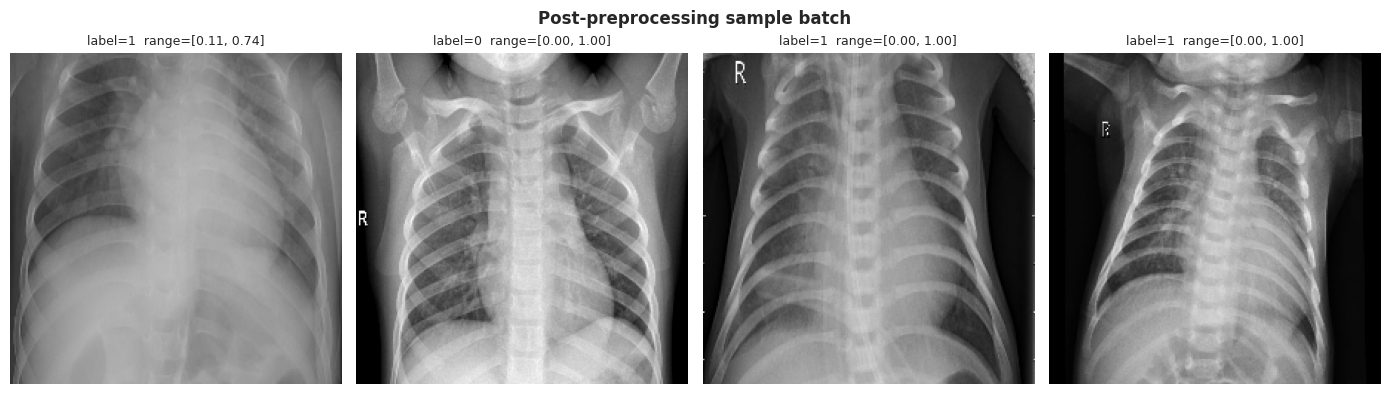

In [8]:
IMG_SIZE   = (224, 224)        # Standard input for ResNet/DenseNet/EfficientNetB0
BATCH_SIZE = 32                # Fits comfortably in Colab T4 GPU memory
LABEL_MODE = "binary"          # Output a single scalar in {0., 1.}
COLOR_MODE = "rgb"             # 3 channels (replicated grayscale) for transfer learning

def load_split(folder_name: str, shuffle: bool):
    """Build a tf.data.Dataset from a split's symlink folder."""
    return tf.keras.utils.image_dataset_from_directory(
        SPLITS_DIR / folder_name,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode=LABEL_MODE,
        color_mode=COLOR_MODE,
        shuffle=shuffle,
        seed=RANDOM_SEED if shuffle else None,
    )

train_ds        = load_split("train",         shuffle=True)
val_ds          = load_split("val",           shuffle=False)
val_original_ds = load_split("val_original",  shuffle=False)
test_ds         = load_split("test",          shuffle=False)

# Confirm class index mapping (alphabetical: NORMAL=0, PNEUMONIA=1)
print("Class indices (alphabetical):", train_ds.class_names)

# === Normalization ===
# Rescaling layer maps uint8 [0, 255] -> float32 [0.0, 1.0]
rescale = tf.keras.layers.Rescaling(1.0 / 255.0)

def preprocess(ds):
    """Normalize, cache, and prefetch for fast training in later weeks."""
    ds = ds.map(lambda x, y: (rescale(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()                                    # Cache after rescaling
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)     # Overlap I/O with training
    return ds

train_ds        = preprocess(train_ds)
val_ds          = preprocess(val_ds)
val_original_ds = preprocess(val_original_ds)
test_ds         = preprocess(test_ds)

# === Smoke test: pull one batch and verify shape + range ===
sample_x, sample_y = next(iter(train_ds))
print(f"\nBatch tensor shape: {sample_x.shape}    (expect (32, 224, 224, 3))")
print(f"Pixel value range : [{sample_x.numpy().min():.3f}, {sample_x.numpy().max():.3f}]"
      f"    (expect [0.000, 1.000])")
print(f"Label tensor shape: {sample_y.shape}   dtype={sample_y.dtype}")
print(f"Label value sample: {sample_y.numpy()[:8].flatten()}")

# Visual confirmation that normalization preserved image content
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    ax.imshow(sample_x[i].numpy())
    ax.set_title(f"label={int(sample_y[i].numpy())}  range=[{sample_x[i].numpy().min():.2f}, "
                 f"{sample_x[i].numpy().max():.2f}]", fontsize=9)
    ax.axis("off")
plt.suptitle("Post-preprocessing sample batch", weight="bold")
plt.tight_layout()
plt.show()